In [5]:
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
dataDirList = ['Garbage_Pictures']
selectedClasses = ['metal', 'glass', 'paper', 'trash', 'cardboard', 'plastic']

In [3]:
imgPaths = []
labels = []
for dataDir in dataDirList:
    for className in os.listdir(dataDir):
        if className in selectedClasses :
            classPath = os.path.join(dataDir,className)
            for img in os.listdir(classPath):
                imgPath = os.path.join(classPath,img)
                imgPaths.append(imgPath)
                labels.append(className)

df = pd.DataFrame({
    'imgPath':imgPaths,
    'label':labels
})

df = df.sample(frac=1).reset_index(drop=True)       

df.head(10)

,imgPath,label
0,archive/Garbage Classification\paper\paper214.jpg,paper
1,archive/Garbage Classification\cardboard\cardb...,cardboard
2,archive/Garbage Classification\paper\paper353.jpg,paper
3,archive/Garbage Classification\cardboard\cardb...,cardboard
4,archive/Garbage Classification\metal\metal123.jpg,metal
5,archive/Garbage Classification\metal\metal401.jpg,metal
6,archive/Garbage Classification\paper\paper232.jpg,paper
7,archive/Garbage Classification\trash\trash11.jpg,trash
8,archive/Garbage Classification\metal\metal271.jpg,metal
9,archive/Garbage Classification\glass\glass228.jpg,glass


In [ ]:
df_gaussian_blur = df.copy()

def apply_gaussian_blur_to_paths(df, save_path):
    for idx, row in df.iterrows():
        image_path = row['imgPath']
        image = cv2.imread(image_path)

        blurred_image = cv2.GaussianBlur(image, (5, 5), 0)

        filename = os.path.basename(image_path)
        blurred_image_path = os.path.join(save_path, f"blurred_{filename}")
        cv2.imwrite(blurred_image_path, blurred_image)

        df.at[idx, 'imgPath'] = blurred_image_path
    
apply_gaussian_blur_to_paths(df_gaussian_blur, save_path='Gaussian_Blured_Pictures') 

In [ ]:
df_edges = df.copy()

def apply_edge_detection_to_paths(df, save_path):
    for idx, row in df.iterrows():
        image_path = row['imgPath']
        image = cv2.imread(image_path)

        edges = cv2.Canny(image, 100, 200)

        filename = os.path.basename(image_path)
        edges_image_path = os.path.join(save_path, f"edges_{filename}")
        cv2.imwrite(edges_image_path, edges)

        df.at[idx, 'imgPath'] = edges_image_path

apply_edge_detection_to_paths(df_edges, save_path='Edge_Detection_Picture') 

In [ ]:
# Comment this after running once
# df.to_csv("Original.csv", index=False)
# df_gaussian_blur.to_csv("Gaussian.csv", index=False)
# df_edges.to_csv("Edges.csv", index=False)

In [3]:
df = pd.read_csv("Dataset/Original.csv")
df_gaussian_blur = pd.read_csv("Dataset/Gaussian.csv")
df_edges = pd.read_csv("Dataset/Edges.csv")

In [ ]:
import cv2
import pandas as pd

sift = cv2.SIFT_create()
def compute_features_sift(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    gray_image = cv2.equalizeHist(gray_image)
    if image is not None:
        keypoints, descriptors = sift.detectAndCompute(gray_image, None)
        descriptors = np.float32(descriptors)
        return keypoints, descriptors
    else:
        return None, None

df_edges["sift_keypoint"], df_edges["sift_descriptor"] = zip(*df_edges["imgPath"].apply(compute_features_sift))
df_gaussian_blur["sift_keypoint"], df_gaussian_blur["sift_descriptor"] = zip(*df_gaussian_blur["imgPath"].apply(compute_features_sift))

akaze = cv2.AKAZE_create()
def compute_features_akaze(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    gray_image = cv2.equalizeHist(gray_image)
    if image is not None:
        keypoints, descriptors = akaze.detectAndCompute(gray_image, None)
        descriptors = np.float32(descriptors)
        return keypoints, descriptors
    else:
        return None, None

df_edges["akaze_keypoint"], df_edges["akaze_descriptor"] = zip(*df_edges["imgPath"].apply(compute_features_akaze))
df_gaussian_blur["akaze_keypoint"], df_gaussian_blur["akaze_descriptor"] = zip(*df_gaussian_blur["imgPath"].apply(compute_features_akaze))

Most matching with:  paper


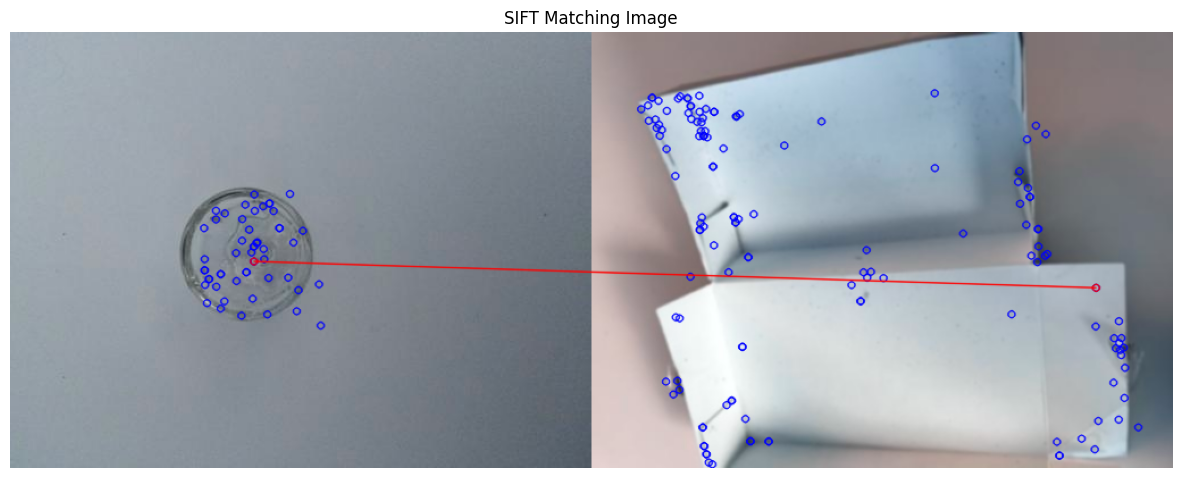

Most matching with:  plastic


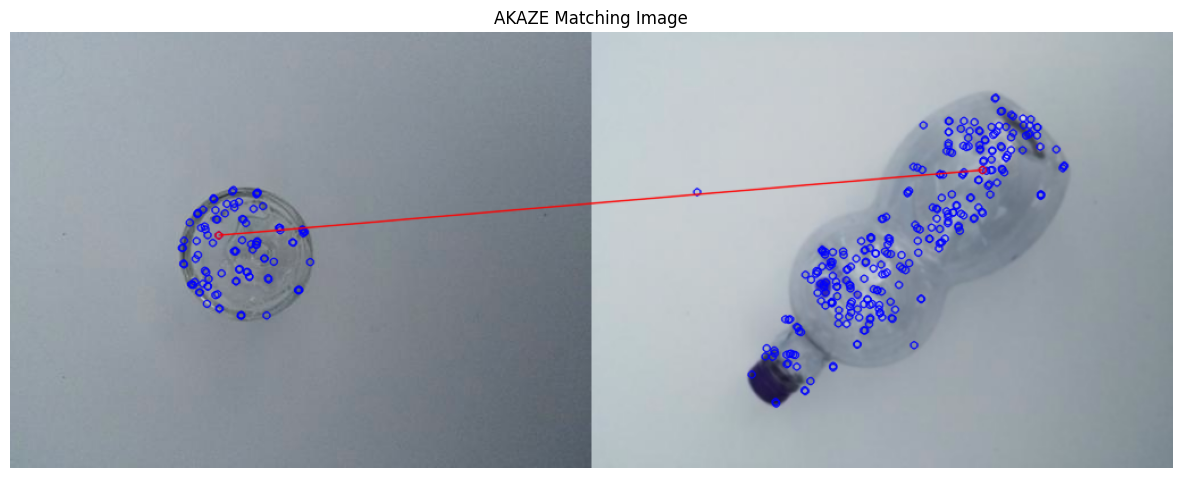

In [18]:
flann = cv2.FlannBasedMatcher(dict(algorithm=1, trees=10), dict(checks=100))

def match_features(df, target):
    target = cv2.imread(target)
    gray_target = cv2.cvtColor(target, cv2.COLOR_BGR2GRAY)
    gray_target = cv2.GaussianBlur(gray_target, (11,11), 0)
    gray_target = cv2.equalizeHist(gray_target)
    
    sift = cv2.SIFT_create()
    target_keypoint, target_descriptor = sift.detectAndCompute(gray_target, None)
    target_descriptor = np.float32(target_descriptor)

    best_matches_data = None
    for _,row in df.iterrows():
        
        sift_descriptor = row['sift_descriptor']

        if sift_descriptor is None:
            continue
        if isinstance(sift_descriptor, np.float32):
            continue
        if sift_descriptor.shape[0] < 2:
            continue

        matches = flann.knnMatch(target_descriptor, sift_descriptor, k=2)
        matchesMask = [[0,0] for _ in range(0, len(matches))]
        current_matches = 0
        best_matches=0

        for i, (fm, sm) in enumerate(matches):
            if fm.distance < 0.7 * sm.distance:
                matchesMask[i] = [1,0]
                current_matches += 1
        
        if best_matches < current_matches:
            best_matches = current_matches
            img = cv2.imread(row['imgPath'])
            best_matches_data = {
                'image_data' : img,
                'keypoint': row['sift_keypoint'],
                'descriptor' : row['sift_descriptor'],
                'match' : matches,
                'matchesmask' : matchesMask,
                'label' : row['label']
            }

    result = cv2.drawMatchesKnn(
        target,
        target_keypoint,
        best_matches_data['image_data'],
        best_matches_data['keypoint'],
        best_matches_data['match'],
        None,
        matchesMask = best_matches_data['matchesmask'],
        matchColor = [255, 0, 0],
        singlePointColor = [0,0,255]
    )
    plt.figure(figsize=(15, 7))
    plt.imshow(result)
    plt.title("SIFT Matching Image")
    plt.axis('off')
    print("Most matching with: ", best_matches_data['label'])

    plt.show()

    # ==================================

    akaze = cv2.AKAZE_create()
    target_keypoint, target_descriptor = akaze.detectAndCompute(gray_target, None)
    target_descriptor = np.float32(target_descriptor)

    best_matches_data = None
    for _,row in df.iterrows():
    
        akaze_descriptor = row['akaze_descriptor']

        if akaze_descriptor is None:
            continue
        if isinstance(akaze_descriptor, np.float32):
            continue
        if akaze_descriptor.shape[0] < 2:
            continue

        matches = flann.knnMatch(target_descriptor, akaze_descriptor, k=2)
        matchesMask = [[0,0] for _ in range(0, len(matches))]
        current_matches = 0
        best_matches=0

        for i, (fm, sm) in enumerate(matches):
            if fm.distance < 0.7 * sm.distance:
                matchesMask[i] = [1,0]
                current_matches += 1
        
        if best_matches < current_matches:
            best_matches = current_matches
            img = cv2.imread(row['imgPath'])
            best_matches_data = {
                'image_data' : img,
                'keypoint': row['akaze_keypoint'],
                'descriptor' : row['akaze_descriptor'],
                'match' : matches,
                'matchesmask' : matchesMask,
                'label' : row['label']
            }

    result = cv2.drawMatchesKnn(
        target,
        target_keypoint,
        best_matches_data['image_data'],
        best_matches_data['keypoint'],
        best_matches_data['match'],
        None,
        matchesMask = best_matches_data['matchesmask'],
        matchColor = [255, 0, 0],
        singlePointColor = [0,0,255]
    )
    plt.figure(figsize=(15, 7))
    plt.imshow(result)
    plt.title("AKAZE Matching Image")
    plt.axis('off')
    print("Most matching with: ", best_matches_data['label'])

    plt.show()

match_features(df_gaussian_blur, "Garbage_Pictures/glass/glass5.jpg")